In [1]:
!pip install pennylane
!pip install timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 50.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 62.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 93.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/

In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import time

# PennyLane imports
import pennylane as qml
from pennylane import numpy as np_qml

In [3]:
# --- Dataset Configuration ---
DATA_DIR = "/kaggle/input/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
VAL_SPLIT = 0.2
RANDOM_SEED = 42
NUM_WORKERS = 2

# --- Quantum Configuration ---
N_QUBITS = 4  # Number of qubits
N_LAYERS = 2  # Number of quantum layers

print("Checking dataset directory...")
if not os.path.exists(DATA_DIR):
    print(" DATA_DIR does not exist:", DATA_DIR)
else:
    print(" Found DATA_DIR:", DATA_DIR)

# --- Data Transformations and Loading ---
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Checking dataset directory...
 Found DATA_DIR: /kaggle/input/BreaKHis_v1/BreaKHis_v1/histology_slides/breast


In [4]:
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
class_names = full_dataset.classes
print("Classes:", class_names)
print("Total images:", len(full_dataset))

Classes: ['benign', 'malignant']
Total images: 7909


In [5]:
# Split dataset
train_size = int((1.0 - VAL_SPLIT) * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=NUM_WORKERS, pin_memory=True)

print(f"Split -> Train: {len(train_dataset)}  Val: {len(val_dataset)}")

Split -> Train: 6327  Val: 1582


In [6]:
# --- Quantum Circuit Definition ---
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    """
    Quantum circuit with data encoding and variational layers
    """
    # Data encoding (supports batched inputs)
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='X')
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    
    # Variational layers
    for layer in range(N_LAYERS):
        # Entangling gates
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])  # Circular connection
        
        # Parameterized gates
        for i in range(N_QUBITS):
            qml.RX(weights[layer, i, 0], wires=i)
            qml.RY(weights[layer, i, 1], wires=i)
            qml.RZ(weights[layer, i, 2], wires=i)
    
    # Measurement
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


In [7]:
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=N_QUBITS, n_layers=N_LAYERS):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        
        # Initialize quantum weights
        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
    
    def forward(self, x):
        # Ensure input has the right dimension for quantum circuit
        if x.size(-1) != self.n_qubits:
            # Project to quantum dimension
            x = torch.tanh(x[..., :self.n_qubits])  # Take first n_qubits features and normalize
        
        return self.qlayer(x)

In [8]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import GoogLeNet_Weights

class HQCNN_GoogleNet_Quantum(nn.Module):
    def __init__(self, num_classes, embed_dim=512, num_heads=8, num_layers=2, 
                 hidden_dim=1024, freeze_backbone=False, use_quantum=True):
        super().__init__()
        
        # Load pretrained GoogLeNet with aux_logits=True (required by weights)
        self.backbone = models.googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)
        
        # Strip auxiliary classifiers (we don’t need them for feature extraction)
        self.backbone.aux_logits = False
        self.backbone.aux1 = nn.Identity()
        self.backbone.aux2 = nn.Identity()
        
        # Grab feature dimension
        feat_dim = self.backbone.fc.in_features
        
        # Replace classification head with identity
        self.backbone.fc = nn.Identity()
        
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        
        self.use_quantum = use_quantum
        self.proj = nn.Linear(feat_dim, embed_dim)
        
        # Quantum layer
        if use_quantum:
            self.quantum_proj = nn.Linear(embed_dim, N_QUBITS)
            self.quantum_layer = QuantumLayer(n_qubits=N_QUBITS, n_layers=N_LAYERS)
            self.quantum_post = nn.Linear(N_QUBITS, embed_dim // 2)
            effective_embed_dim = embed_dim + embed_dim // 2
        else:
            effective_embed_dim = embed_dim
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=effective_embed_dim, 
            nhead=num_heads, 
            dim_feedforward=hidden_dim, 
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head
        self.dropout = nn.Dropout(0.3)
        self.fc_out = nn.Linear(effective_embed_dim, num_classes)
    
    def forward(self, x):
        # Extract features from GoogLeNet backbone
        feat = self.backbone(x)  # [B, feat_dim]
        feat = self.proj(feat)   # [B, embed_dim]
        
        if self.use_quantum:
            quantum_input = self.quantum_proj(feat)         # [B, n_qubits]
            quantum_output = self.quantum_layer(quantum_input)  # [B, n_qubits]
            quantum_feat = self.quantum_post(quantum_output)    # [B, embed_dim//2]
            
            combined_feat = torch.cat([feat, quantum_feat], dim=1)  # [B, effective_embed_dim]
        else:
            combined_feat = feat
        
        combined_feat = combined_feat.unsqueeze(1)  # [B, 1, effective_embed_dim]
        transformer_out = self.transformer(combined_feat)  # [B, 1, effective_embed_dim]
        transformer_out = transformer_out.squeeze(1)  # [B, effective_embed_dim]
        
        output = self.dropout(transformer_out)
        output = self.fc_out(output)
        
        return output


In [9]:
def count_parameters(model):
    """Count total and trainable parameters"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

In [10]:
def measure_inference_time(model, data_loader, device, num_batches=5):
    """Measure average inference time"""
    model.eval()
    times = []
    
    with torch.no_grad():
        for i, (inputs, _) in enumerate(data_loader):
            if i >= num_batches:
                break
            
            inputs = inputs.to(device)
            
            # Warm up GPU
            if i == 0:
                _ = model(inputs)
                torch.cuda.synchronize() if device.type == 'cuda' else None
            
            start_time = time.time()
            _ = model(inputs)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end_time = time.time()
            
            times.append(end_time - start_time)
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    return avg_time, std_time

In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
               device, num_epochs=10, save_path='best_hqcnn_quantum.pth'):
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    model.to(device)
    
    for epoch in range(num_epochs):
        t0 = time.time()
        
        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)
        
        train_loss = running_loss / total
        train_acc = running_corrects.double().item() / total
        
        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)
                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)
                val_total += labels.size(0)
        
        val_loss = val_running_loss / val_total
        val_acc = val_running_corrects.double().item() / val_total
        
        # Update learning rate
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
        
        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} '
              f'- Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f} - LR: {current_lr:.6f} - Time: {elapsed:.1f}s')
    
    return history

In [12]:
# --- Model Training ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Create quantum model
model_quantum = HQCNN_GoogleNet_Quantum(
    num_classes=len(class_names), 
    use_quantum=True,
    freeze_backbone=False
).to(device)

# Create classical model for comparison
model_classical = HQCNN_GoogleNet_Quantum(
    num_classes=len(class_names), 
    use_quantum=False,
    freeze_backbone=False
).to(device)

# Print parameter counts
quantum_total, quantum_trainable = count_parameters(model_quantum)
classical_total, classical_trainable = count_parameters(model_classical)

print(f"\n=== MODEL COMPARISON ===")
print(f"Quantum Model:")
print(f"  Total parameters: {quantum_total:,}")
print(f"  Trainable parameters: {quantum_trainable:,}")

print(f"\nClassical Model:")
print(f"  Total parameters: {classical_total:,}")
print(f"  Trainable parameters: {classical_trainable:,}")

print(f"\nParameter difference: {quantum_total - classical_total:,} (+{((quantum_total/classical_total - 1) * 100):.1f}%)")

Device: cuda


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth
100%|██████████| 49.7M/49.7M [00:00<00:00, 99.7MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(



=== MODEL COMPARISON ===
Quantum Model:
  Total parameters: 14,009,790
  Trainable parameters: 14,009,790

Classical Model:
  Total parameters: 10,331,298
  Trainable parameters: 10,331,298

Parameter difference: 3,678,492 (+35.6%)


In [13]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer_quantum = torch.optim.AdamW(model_quantum.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_quantum = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_quantum, patience=2, factor=0.5)

optimizer_classical = torch.optim.AdamW(model_classical.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_classical = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_classical, patience=2, factor=0.5)

NUM_EPOCHS = 10

print(f"\n=== TRAINING QUANTUM MODEL ===")
history_quantum = train_model(
    model_quantum, train_loader, val_loader, criterion, optimizer_quantum, scheduler_quantum,
    device, num_epochs=NUM_EPOCHS, save_path='best_hqcnn_quantum.pth'
)

print(f"\n=== TRAINING CLASSICAL MODEL ===")
history_classical = train_model(
    model_classical, train_loader, val_loader, criterion, optimizer_classical, scheduler_classical,
    device, num_epochs=NUM_EPOCHS, save_path='best_hqcnn_classical.pth'
)


=== TRAINING QUANTUM MODEL ===
Epoch 1/10 - Train Loss: 0.3222 Train Acc: 0.8555 - Val Loss: 0.1565 Val Acc: 0.9399 - LR: 0.000100 - Time: 108.0s
Epoch 2/10 - Train Loss: 0.1441 Train Acc: 0.9455 - Val Loss: 0.1082 Val Acc: 0.9576 - LR: 0.000100 - Time: 76.4s
Epoch 3/10 - Train Loss: 0.0842 Train Acc: 0.9706 - Val Loss: 0.0926 Val Acc: 0.9627 - LR: 0.000100 - Time: 75.5s
Epoch 4/10 - Train Loss: 0.0699 Train Acc: 0.9733 - Val Loss: 0.1051 Val Acc: 0.9716 - LR: 0.000100 - Time: 74.4s
Epoch 5/10 - Train Loss: 0.0615 Train Acc: 0.9771 - Val Loss: 0.0966 Val Acc: 0.9690 - LR: 0.000100 - Time: 76.6s
Epoch 6/10 - Train Loss: 0.0445 Train Acc: 0.9848 - Val Loss: 0.0945 Val Acc: 0.9697 - LR: 0.000050 - Time: 74.8s
Epoch 7/10 - Train Loss: 0.0293 Train Acc: 0.9896 - Val Loss: 0.1150 Val Acc: 0.9716 - LR: 0.000050 - Time: 74.1s
Epoch 8/10 - Train Loss: 0.0128 Train Acc: 0.9945 - Val Loss: 0.1164 Val Acc: 0.9709 - LR: 0.000050 - Time: 74.7s
Epoch 9/10 - Train Loss: 0.0244 Train Acc: 0.9930 - Val

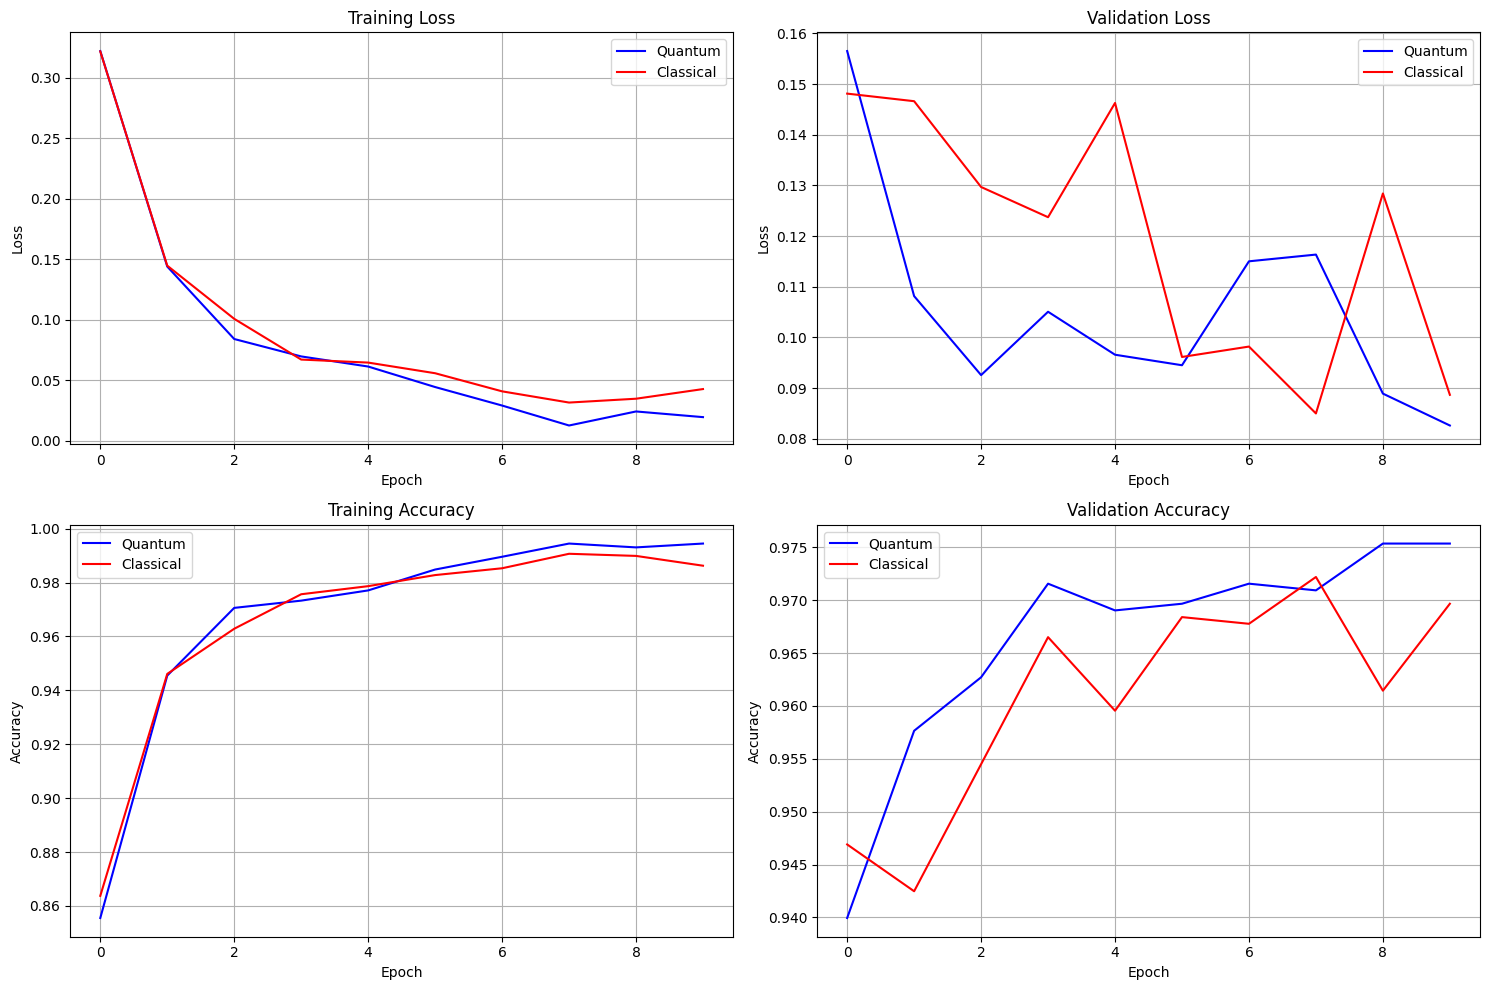

In [14]:
# --- Performance Comparison ---
def plot_comparison(history_quantum, history_classical):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Training Loss
    ax1.plot(history_quantum['train_loss'], label='Quantum', color='blue')
    ax1.plot(history_classical['train_loss'], label='Classical', color='red')
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Validation Loss
    ax2.plot(history_quantum['val_loss'], label='Quantum', color='blue')
    ax2.plot(history_classical['val_loss'], label='Classical', color='red')
    ax2.set_title('Validation Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    # Training Accuracy
    ax3.plot(history_quantum['train_acc'], label='Quantum', color='blue')
    ax3.plot(history_classical['train_acc'], label='Classical', color='red')
    ax3.set_title('Training Accuracy')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Accuracy')
    ax3.legend()
    ax3.grid(True)
    
    # Validation Accuracy
    ax4.plot(history_quantum['val_acc'], label='Quantum', color='blue')
    ax4.plot(history_classical['val_acc'], label='Classical', color='red')
    ax4.set_title('Validation Accuracy')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Accuracy')
    ax4.legend()
    ax4.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_comparison(history_quantum, history_classical)

In [15]:
print(f"\n=== INFERENCE TIME COMPARISON ===")

# Load best models
model_quantum.load_state_dict(torch.load('best_hqcnn_quantum.pth', map_location=device))
model_classical.load_state_dict(torch.load('best_hqcnn_classical.pth', map_location=device))

# Measure inference times
quantum_time, quantum_std = measure_inference_time(model_quantum, val_loader, device)
classical_time, classical_std = measure_inference_time(model_classical, val_loader, device)

print(f"Quantum Model - Avg inference time: {quantum_time:.4f}s (±{quantum_std:.4f}s)")
print(f"Classical Model - Avg inference time: {classical_time:.4f}s (±{classical_std:.4f}s)")
print(f"Quantum overhead: {((quantum_time/classical_time - 1) * 100):.1f}%")


=== INFERENCE TIME COMPARISON ===
Quantum Model - Avg inference time: 0.0565s (±0.0026s)
Classical Model - Avg inference time: 0.0264s (±0.0002s)
Quantum overhead: 113.6%


In [16]:
def evaluate_model(model, data_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    
    return all_labels, all_preds

print(f"\n=== FINAL EVALUATION ===")

# Quantum model evaluation
all_labels_q, all_preds_q = evaluate_model(model_quantum, val_loader, device, class_names)
print('\nQuantum Model - Classification Report:')
print(classification_report(all_labels_q, all_preds_q, target_names=class_names))

# Classical model evaluation  
all_labels_c, all_preds_c = evaluate_model(model_classical, val_loader, device, class_names)
print('\nClassical Model - Classification Report:')
print(classification_report(all_labels_c, all_preds_c, target_names=class_names))


=== FINAL EVALUATION ===

Quantum Model - Classification Report:
              precision    recall  f1-score   support

      benign       0.96      0.96      0.96       502
   malignant       0.98      0.98      0.98      1080

    accuracy                           0.98      1582
   macro avg       0.97      0.97      0.97      1582
weighted avg       0.98      0.98      0.98      1582


Classical Model - Classification Report:
              precision    recall  f1-score   support

      benign       0.95      0.97      0.96       502
   malignant       0.99      0.97      0.98      1080

    accuracy                           0.97      1582
   macro avg       0.97      0.97      0.97      1582
weighted avg       0.97      0.97      0.97      1582



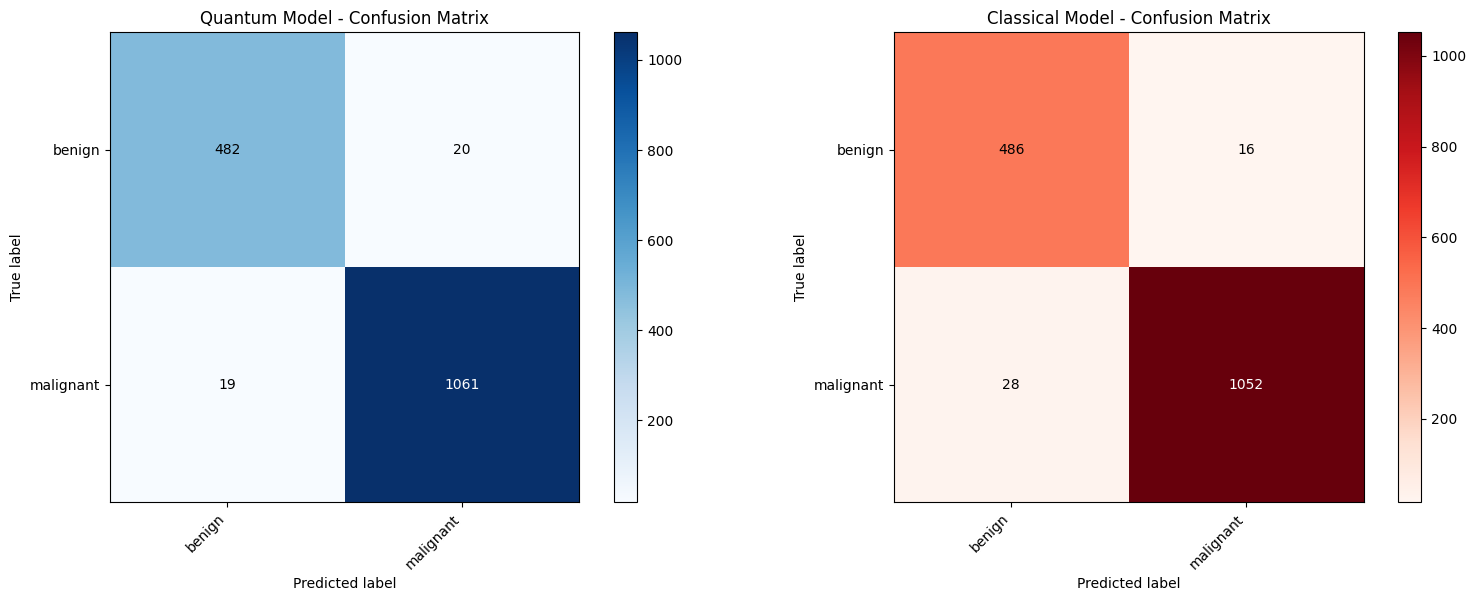


=== SUMMARY ===
Best Validation Accuracy:
  Quantum Model: 0.9753
  Classical Model: 0.9722
  Improvement: 0.0032


In [17]:
# Confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Quantum confusion matrix
cm_q = confusion_matrix(all_labels_q, all_preds_q)
im1 = ax1.imshow(cm_q, interpolation='nearest', cmap=plt.cm.Blues)
ax1.set_title('Quantum Model - Confusion Matrix')
ax1.figure.colorbar(im1, ax=ax1)
ticks = np.arange(len(class_names))
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.set_xticklabels(class_names, rotation=45, ha='right')
ax1.set_yticklabels(class_names)

thresh = cm_q.max() / 2.
for i in range(cm_q.shape[0]):
    for j in range(cm_q.shape[1]):
        ax1.text(j, i, format(cm_q[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm_q[i, j] > thresh else 'black')

ax1.set_ylabel('True label')
ax1.set_xlabel('Predicted label')

# Classical confusion matrix
cm_c = confusion_matrix(all_labels_c, all_preds_c)
im2 = ax2.imshow(cm_c, interpolation='nearest', cmap=plt.cm.Reds)
ax2.set_title('Classical Model - Confusion Matrix')
ax2.figure.colorbar(im2, ax=ax2)
ax2.set_xticks(ticks)
ax2.set_yticks(ticks)
ax2.set_xticklabels(class_names, rotation=45, ha='right')
ax2.set_yticklabels(class_names)

thresh = cm_c.max() / 2.
for i in range(cm_c.shape[0]):
    for j in range(cm_c.shape[1]):
        ax2.text(j, i, format(cm_c[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm_c[i, j] > thresh else 'black')

ax2.set_ylabel('True label')
ax2.set_xlabel('Predicted label')

plt.tight_layout()
plt.show()

print(f"\n=== SUMMARY ===")
print(f"Best Validation Accuracy:")
print(f"  Quantum Model: {max(history_quantum['val_acc']):.4f}")
print(f"  Classical Model: {max(history_classical['val_acc']):.4f}")
print(f"  Improvement: {(max(history_quantum['val_acc']) - max(history_classical['val_acc'])):.4f}")